In [63]:
from datasets import load_dataset
import matplotlib.pyplot as plt

In [64]:
ds = load_dataset("cambridgeltl/vsr_zeroshot")

Index(['image', 'image_link', 'caption', 'label', 'relation', 'subj', 'obj',
       'annotator_id', 'vote_true_validator_id', 'vote_false_validator_id'],
      dtype='object')


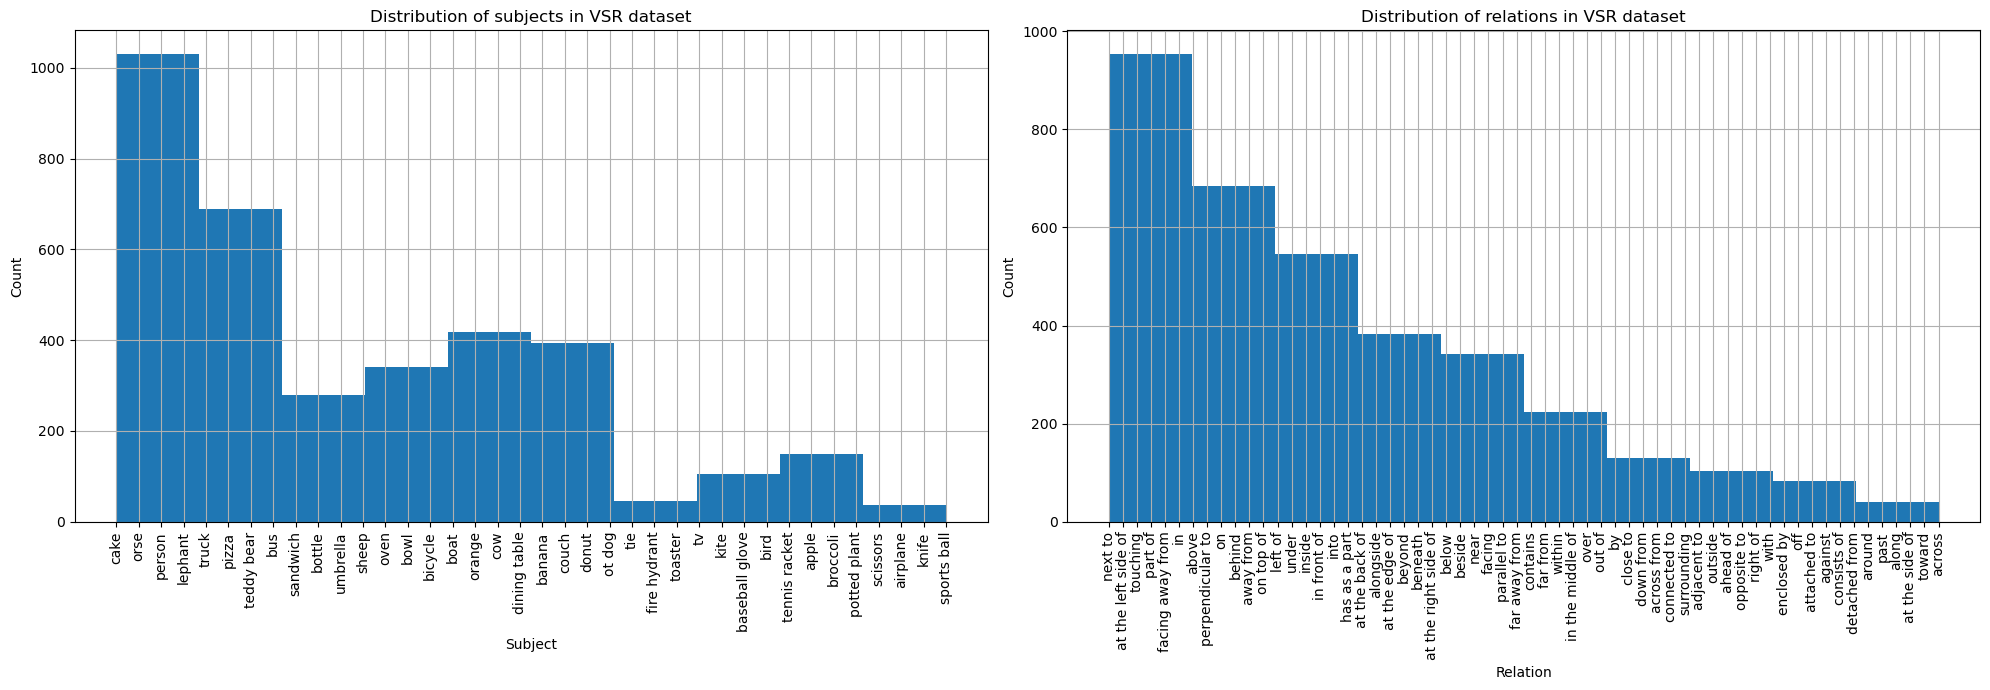

In [65]:
df = ds["train"].to_pandas()

print(df.columns)

plt.figure(figsize=(20, 7))
plt.subplot(121)
df['subj'].hist()
plt.xticks(rotation=90)
plt.title("Distribution of subjects in VSR dataset")
plt.xlabel("Subject")
plt.ylabel("Count")

plt.subplot(122)
df['relation'].hist()
plt.xticks(rotation=90)
plt.title("Distribution of relations in VSR dataset")
plt.xlabel("Relation")
plt.ylabel("Count")
plt.tight_layout()

plt.show()

<Axes: xlabel='relation'>

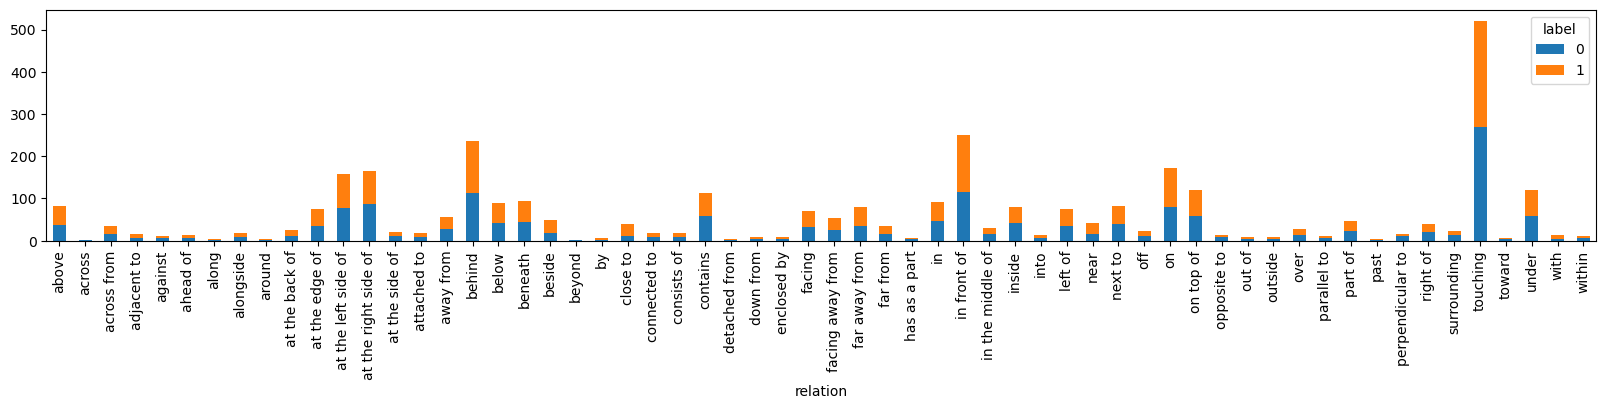

In [66]:
# Plot bars per relation where lower part of bar is quantity of label = 0 and upper part (in different color) is label = 1 -> df[['relation', 'label']]
df[['relation', 'label']].groupby(['relation', 'label']).size().unstack().plot(kind='bar', stacked=True, figsize=(20, 3))

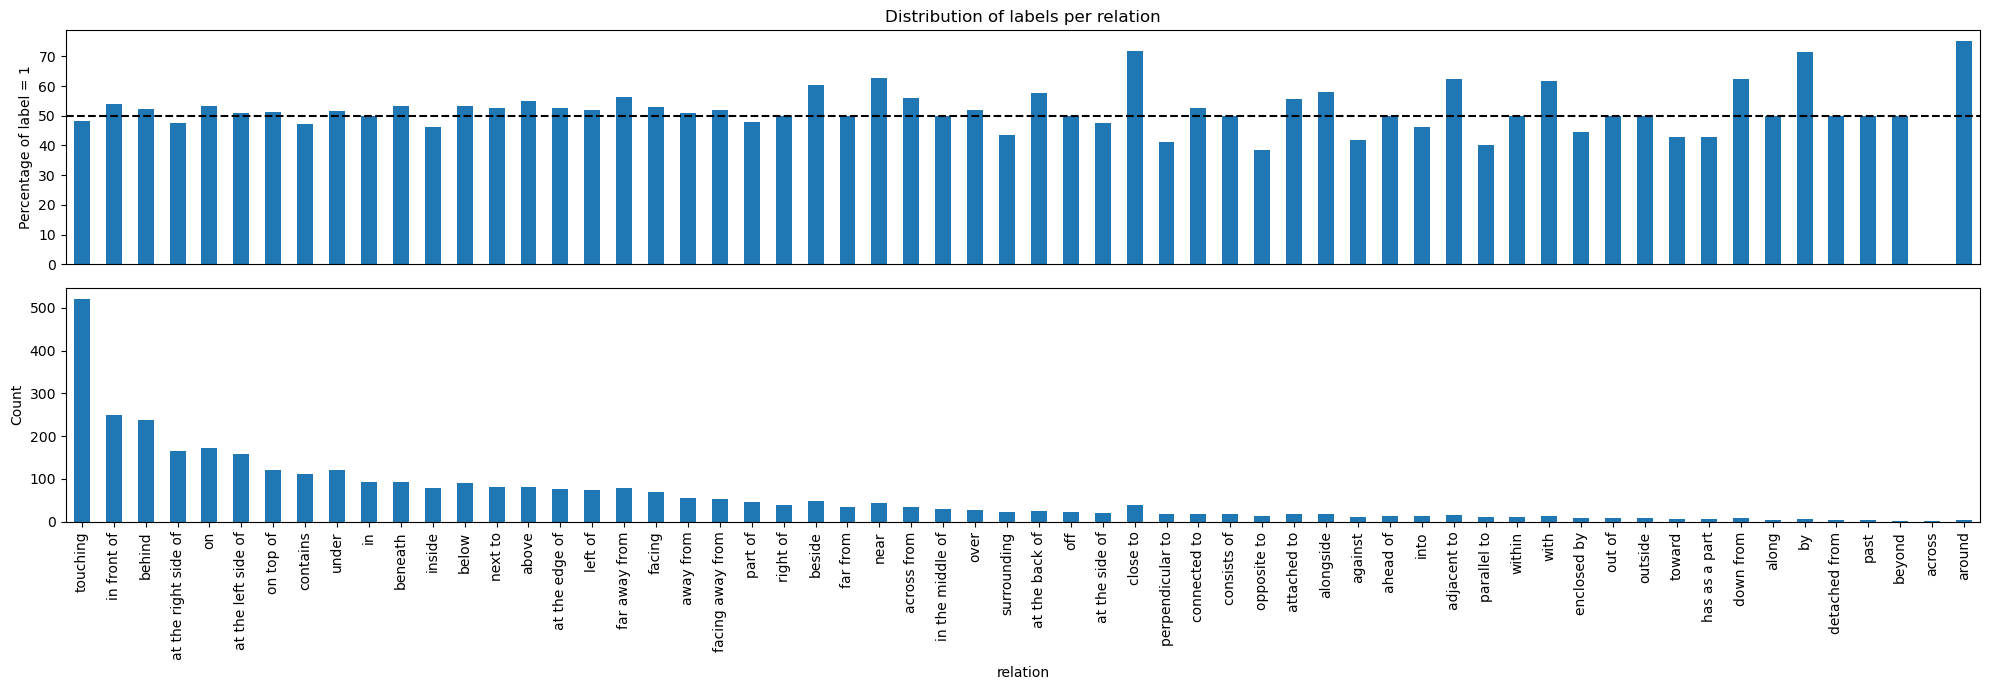

In [67]:

# Sort by count of relation
sorted_df = df[['relation', 'label']].groupby(['relation', 'label']).size().unstack().fillna(0).reset_index()
sorted_df = sorted_df.sort_values(by=0, ascending=False)
sorted_df = sorted_df.set_index('relation')

plt.figure(figsize=(20, 7))
plt.subplot(211)
(sorted_df[1] / (sorted_df[0] + sorted_df[1]) * 100).plot(kind='bar', ax=plt.gca())
plt.xticks([])
plt.xlabel('')
plt.ylabel("Percentage of label = 1")

plt.title("Distribution of labels per relation")
plt.axhline(y=50, color='black', linestyle='--')

plt.subplot(212)
(sorted_df[0] + sorted_df[1]).plot(kind='bar', ax=plt.gca())
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [68]:
# Assume your dataframe is called df and has columns 'relation' and 'label'
group_means = df.groupby('relation')['label'].mean()

# Predict by mapping each 'relation' to its group mean
df['prediction'] = df['relation'].map(group_means)

# If you want to compute R² manually:
from sklearn.metrics import r2_score
r2 = r2_score(df['label'], df['prediction'])

print(f"GroupMeans R²: {r2:.4f}")

n = len(df)
p = df['relation'].nunique() - 1  # Minus 1 since one is the reference in dummy encoding
r2_adj = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

print(f"R²: {r2:.4f}, Adjusted R²: {r2_adj:.4f}")


GroupMeans R²: 0.0079
R²: 0.0079, Adjusted R²: -0.0091


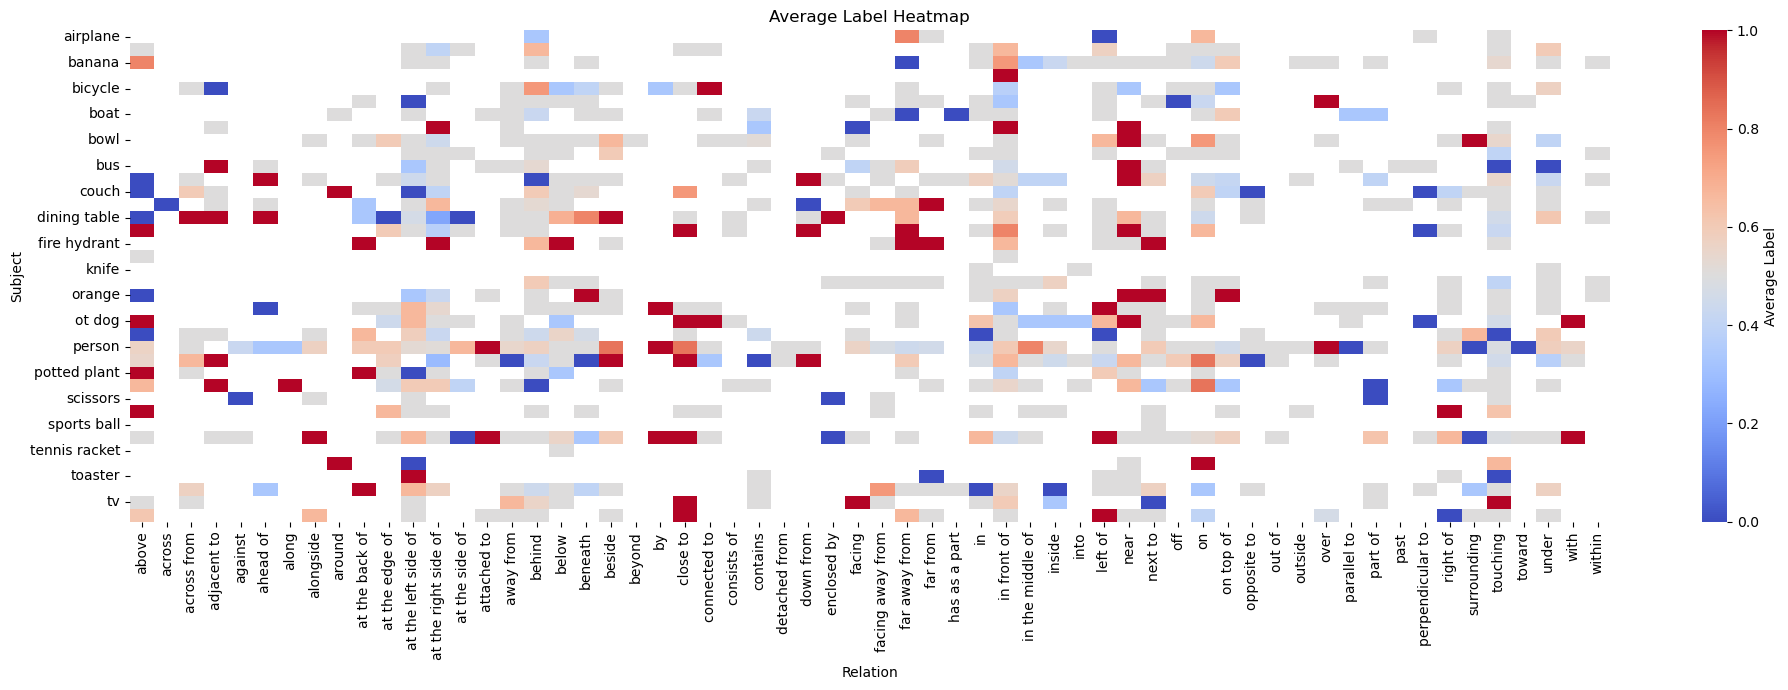

In [69]:
# Use subject and relation columns and show the average label in a heatmap
import seaborn as sns
import numpy as np

# Create a pivot table
pivot_table = df.pivot_table(index='subj', columns='relation', values='label', aggfunc="mean")
# Create a heatmap
plt.figure(figsize=(20, 7))
sns.heatmap(pivot_table, cmap='coolwarm', cbar_kws={'label': 'Average Label'})
plt.title("Average Label Heatmap")
plt.xlabel("Relation")
plt.ylabel("Subject")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [70]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Fit a linear regression model
model = smf.ols('label ~ relation', data=df).fit()
# Print the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  label   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.4648
Date:                Mon, 21 Apr 2025   Prob (F-statistic):               1.00
Time:                        22:29:44   Log-Likelihood:                -2516.7
No. Observations:                3489   AIC:                             5153.
Df Residuals:                    3429   BIC:                             5523.
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [71]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier      # or LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import set_config
set_config(transform_output="pandas")              # keeps output tidy (sk‑learn ≥1.4)

X_text = df["caption"]
y       = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.1, random_state=42, stratify=y
)

# ------------------------------------------------------------------
# 3.  Build a pipeline: TF‑IDF → linear classifier
#     • sublinear_tf = True often helps with short captions
#     • class_weight = "balanced" hedges against class imbalance
#     • loss = "log_loss" gives calibrated probabilities
# ------------------------------------------------------------------
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        stop_words="english",
        ngram_range=(1,2),
        sublinear_tf=True
    )),
    ("clf", SGDClassifier(
        loss="log_loss",         # logistic regression in SGD clothing
        penalty="l2",
        alpha=1e-4,
        max_iter=1000,
        tol=1e-3,
        random_state=0,
        class_weight="balanced"
    ))
])

pipe.fit(X_train, y_train)

# hard 0/1 predictions
y_pred = pipe.predict(X_test)
print("ROC‑AUC (labels):", roc_auc_score(y_test, y_pred).round(4))

# probability predictions (if you care about ranking)
y_proba = pipe.predict_proba(X_test)[:, 1]
print("ROC‑AUC (proba) :", roc_auc_score(y_test, y_proba).round(4))

print(classification_report(y_test, y_pred, digits=3))

ROC‑AUC (labels): 0.307
ROC‑AUC (proba) : 0.241
              precision    recall  f1-score   support

           0      0.298     0.320     0.309       169
           1      0.315     0.294     0.305       180

    accuracy                          0.307       349
   macro avg      0.307     0.307     0.307       349
weighted avg      0.307     0.307     0.307       349



In [72]:
from sklearn.neural_network import MLPClassifier

# ------------------------------------------------------------------
# 3.  Build a pipeline: TF‑IDF → linear classifier
#     • sublinear_tf = True often helps with short captions
#     • class_weight = "balanced" hedges against class imbalance
#     • loss = "log_loss" gives calibrated probabilities
# ------------------------------------------------------------------
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        stop_words="english",
        ngram_range=(1,2),
        sublinear_tf=True
    )),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size='auto',
        learning_rate_init=0.001,
        max_iter=200,
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

# hard 0/1 predictions
y_pred = pipe.predict(X_test)
print("ROC‑AUC (labels):", roc_auc_score(y_test, y_pred).round(4))

# probability predictions (if you care about ranking)
y_proba = pipe.predict_proba(X_test)[:, 1]
print("ROC‑AUC (proba) :", roc_auc_score(y_test, y_proba).round(4))

print(classification_report(y_test, y_pred, digits=3))

ROC‑AUC (labels): 0.2654
ROC‑AUC (proba) : 0.188
              precision    recall  f1-score   support

           0      0.236     0.231     0.234       169
           1      0.293     0.300     0.297       180

    accuracy                          0.266       349
   macro avg      0.265     0.265     0.265       349
weighted avg      0.266     0.266     0.266       349



## Vision Bias

In [73]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from einops import rearrange, repeat
import matplotlib.pyplot as plt


In [74]:
from datasets import load_from_disk
import os
from dotenv import load_dotenv
load_dotenv()

disk_loc = os.path.join(os.environ["DATA_PATH"], "vsr")

In [75]:
from datasets import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm

image_size = 48
batch_size = 64
num_workers = 8

dataset = load_from_disk(disk_loc)

transform = transforms.Compose([
    transforms.Resize((image_size, image_size), antialias=True),
    transforms.ToTensor(),          # → float tensor in [0,1]
])

def add_pixel_values(example):
    img = Image.open(example["image_path"]).convert("RGB")
    example["pixel_values"] = transform(img)
    return example

for split in dataset.keys():
    dataset[split] = dataset[split].map(
        add_pixel_values,
        remove_columns=["image_path"],              # drop once it’s inside pixel_values
        num_proc=num_workers,                       # parallel workers (optional)
    )

# ------------------------------------------------------------------
# 6. Tell datasets to yield PyTorch tensors
# ------------------------------------------------------------------
dataset.set_format(type="torch",
                   columns=["pixel_values", "label"], output_all_columns=False)  # include any columns you need


loader_train = DataLoader(dataset['train'], batch_size=batch_size, num_workers=num_workers, shuffle=True, drop_last=True)
loader_val = DataLoader(dataset['validation'], batch_size=batch_size, num_workers=num_workers, drop_last=False)
loader_test = DataLoader(dataset['test'], batch_size=batch_size, num_workers=num_workers, drop_last=False)



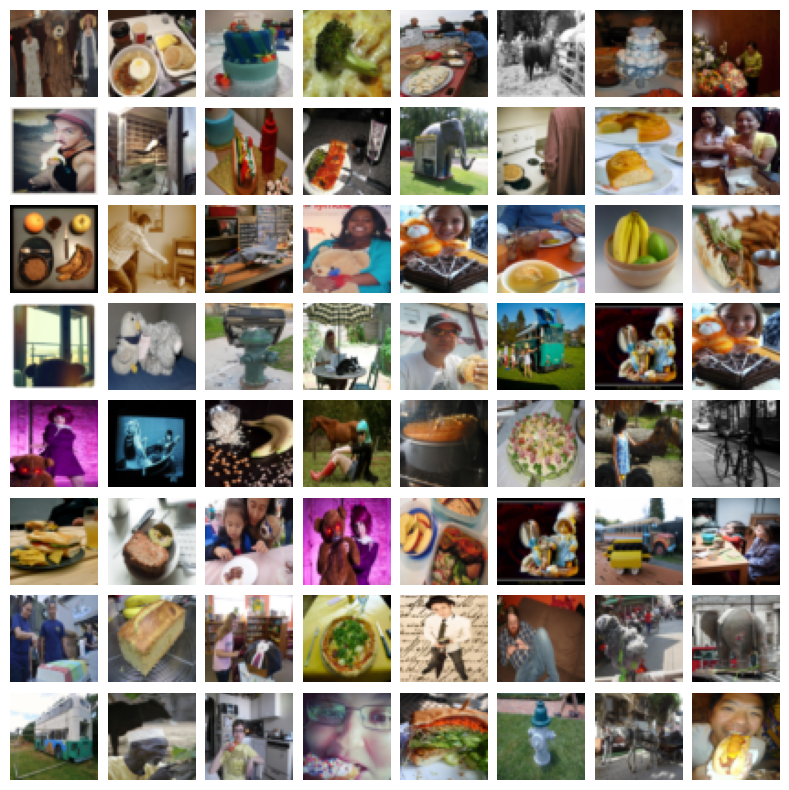

In [76]:
from mpl_toolkits.axes_grid1 import ImageGrid

batch      = next(iter(loader_train))
imgs       = batch["pixel_values"]      # (B, C, 14, 14)
cls_idxs   = batch["label"]             # (B,)

fig = plt.figure(figsize=(10, 10))
grid = ImageGrid(fig, 111, nrows_ncols=(8, 8), axes_pad=0.1)

for ax, img in zip(grid, imgs):         # imgs is a tensor now
    ax.imshow(img.squeeze().permute(1,2,0).numpy(), cmap='gray')  # or .permute(1,2,0) for RGB
    ax.axis("off")

plt.show()


In [77]:
class Mlp(nn.Module):
    def __init__(self, dim, mlp_ratio=4.):
        super().__init__()
        
        mlp_dim = int(dim * mlp_ratio)

        self.mlp_layers = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim)
        )

    def forward(self, x):
        
        return self.mlp_layers(x)
    
class Attention(nn.Module):
    def __init__(self, dim, num_heads=8):
        '''
        Self-attention layer.
        
        params:
            :dim: Dimensionality of each token
            :num_heads: Number of attention heads
        '''
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        # TODO: Define here the linear layers producing K, Q, V from the input x

        # We map to full dim and we will reshape later to split the heads (but doing as so doesn't change the model)
        self.K = nn.Linear(dim, dim, bias=False)
        self.Q = nn.Linear(dim, dim, bias=False)

        # The paper uses d_k = d_v, so we will do the same
        self.V = nn.Linear(dim, dim, bias=False)
        
        # Projection
        self.proj = nn.Linear(dim, dim)

    def forward(self, x, mask=None):
        '''
        Performs a forward pass through the multi-headed self-attention layer.
        
        params:
            :x: Input of shape [B N C]. B = batch size, N = sequence length, C = token dimensionality
            :mask: Optional attention mask of shape [B N N]. Wherever it is True, the attention matrix will
            be zero.
            
        returns:
            Output of shape [B N C].
        '''
        B, N, C = x.shape
        
        # TODO: Compute the keys K, queries Q, and values V from x. Each should be of shape [B num_heads N head_dim].
        q = self.Q(x).reshape(B, N, self.num_heads, -1).transpose(1, 2)
        k = self.K(x).reshape(B, N, self.num_heads, -1).transpose(1, 2)
        v = self.V(x).reshape(B, N, self.num_heads, -1).transpose(1, 2)

        # TODO: Compute the attention matrix (pre softmax) and scale it by 1/sqrt(d_k). It should be of shape [B num_heads N N].
        attn = q @ k.transpose(-2, -1) * self.scale

        if mask is not None:
            mask = rearrange(mask, "b n1 n2 -> b 1 n1 n2")
            # TODO: Apply the optional attention mask. Wherever the mask is True, replace the attention 
            # matrix value by negative infinity → zero attention weight after softmax.
            attn = attn.masked_fill(mask, float('-inf'))

        # TODO: Compute the softmax over the last dimension
        attn = F.softmax(attn, dim=-1)

        # TODO: Weight the values V by the attention matrix and concatenate the different attention heads
        x = attn @ v
        x = x.reshape(B, N, -1)
        
        # One final projection
        x = self.proj(x)
        return x
    
class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.):
        '''
        Transformer encoder block.
        
        params:
            :dim: Dimensionality of each token
            :num_heads: Number of attention heads
            :mlp_ratio: MLP hidden dimensionality multiplier
        '''
        super().__init__()
        
        self.layer_norm_x = nn.LayerNorm(dim)
        self.att = Attention(dim, num_heads)

        self.layer_norm_xa = nn.LayerNorm(dim)
        self.mlp = Mlp(dim, mlp_ratio)

    def forward(self, x, mask=None):
        '''
        Performs a forward pass through the multi-headed self-attention layer.
        
        params:
            :x: Input of shape [B N C]. B = batch size, N = sequence length, C = token dimensionality
            :mask: Optional attention mask of shape [B N N]. Wherever it is True, the attention matrix will
            be zero.
            
        returns:
            Output of shape [B N C].
        '''
        
        X_a = self.att(self.layer_norm_x(x), mask) + x
        X_b = self.mlp(self.layer_norm_xa(X_a)) + X_a

        return X_b
    
class PatchEmbed(nn.Module):
    def __init__(self, img_size=14, patch_size=2, in_channels=1, embed_dim=192):
        '''
        Image to Patch Embedding.
        
        params:
            :img_size: Image height and width in pixels
            :patch_size: Patch size height and width in pixels
            :in_channels: Number of input channels
            :embed_dim: Token dimension
        '''
        super().__init__()
        
        self.patch_size = patch_size
        self.projection = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)


    def forward(self, x):
        '''
        Performs a forward pass through the patch embedding.
        
        params:
            :x: Input of shape [B C H W]. B = batch size, C = number of channels, H = image height, W = image width
            
        returns:
            Output of shape [B N C].
        '''
        y = self.projection(x)
        y = rearrange(y, "b c h w -> b (h w) c")

        return y

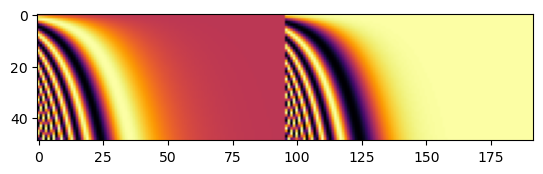

/home/delsad/VI/VLM-R1/.pixi/envs/default/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1744247799952/work/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


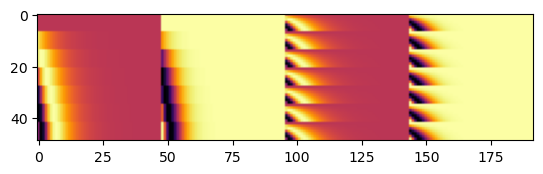

In [78]:
def build_1d_sincos_posemb(max_len, embed_dim=1024, temperature=10000.):
    """Sine-cosine positional embeddings from MoCo-v3, adapted back to 1d
    Returns positional embedding of shape [1, N, D]
    """
    arange = torch.arange(max_len, dtype=torch.float32)
    assert embed_dim % 2 == 0, 'Embed dimension must be divisible by 2 for 1D sin-cos position embedding'
    pos_dim = embed_dim // 2
    omega = torch.arange(pos_dim, dtype=torch.float32) / pos_dim
    omega = 1. / (temperature ** omega)
    out = torch.einsum('m,d->md', [arange, omega])
    pos_emb = torch.cat([torch.sin(out), torch.cos(out)], dim=1)[None, :, :]
    return pos_emb

def build_2d_sincos_posemb(h, w, embed_dim=1024, temperature=10000.):
    """Sine-cosine positional embeddings from MoCo-v3
    Source: https://github.com/facebookresearch/moco-v3/blob/main/vits.py
    Returns positional embedding of shape [B, N, D]
    """
    grid_w = torch.arange(w, dtype=torch.float32)
    grid_h = torch.arange(h, dtype=torch.float32)
    grid_w, grid_h = torch.meshgrid(grid_w, grid_h)
    assert embed_dim % 4 == 0, 'Embed dimension must be divisible by 4 for 2D sin-cos position embedding'
    pos_dim = embed_dim // 4
    omega = torch.arange(pos_dim, dtype=torch.float32) / pos_dim
    omega = 1. / (temperature ** omega)
    out_w = torch.einsum('m,d->md', [grid_w.flatten(), omega])
    out_h = torch.einsum('m,d->md', [grid_h.flatten(), omega])
    pos_emb = torch.cat([torch.sin(out_w), torch.cos(out_w), torch.sin(out_h), torch.cos(out_h)], dim=1)[None, :, :]
    return pos_emb

plt.imshow(build_1d_sincos_posemb(49,192)[0], cmap='inferno')
plt.show()
plt.imshow(build_2d_sincos_posemb(7,7,192)[0], cmap='inferno')
plt.show()

In [79]:
class ViT(nn.Module):
    
    def __init__(self, 
                 img_size=14, 
                 patch_size=2, 
                 in_channels=1, 
                 embed_dim=192, 
                 num_classes=10, 
                 depth=4, 
                 num_heads=4, 
                 mlp_ratio=4., 
                 **kwargs):
        '''
        A Vision Transformer for classification.
        
        params:
            :img_size: Image height and width in pixels
            :patch_size: Patch size height and width in pixels
            :in_channels: Number of input channels
            :embed_dim: Token dimension
            :num_classes: Number of classes
            :depth: Transformer depth
            :num_heads: Number of attention heads
            :mlp_ratio: MLP hidden dimensionality multiplier
        '''
        super().__init__()
        
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, embed_dim)
        self.pos_embed = nn.Parameter(
            build_2d_sincos_posemb(image_size//patch_size, image_size//patch_size, embed_dim=embed_dim), 
            requires_grad=False
        )
        
        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio)
            for i in range(depth)
        ])
        self.head = nn.Linear(embed_dim, num_classes, bias=False)
            
    def forward(self, x):
        '''
        Forward pass through the ViT.
        
        params:
            :x: Input of shape [B C H W]. B = batch size, C = number of channels, H = image height, W = image width
            
        returns:
            Output of shape [B num_classes]
        '''        
        # TODO: Project images to patches
        x = self.patch_embed(x)
        
        # TODO: Add the positional embeddings to the tokens
        x += self.pos_embed
            
        # TODO: Forward pass through Transformer blocks
        for block in self.blocks:
            x = block(x)
            
        # TODO: Perform average pooling (compute the mean over the sequences)
        x = x.mean(dim=1)
        
        # TODO: Compute the logits
        x = self.head(x)

        return x

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [81]:
vit = ViT(
    img_size=image_size, patch_size=2, in_channels=3, 
    embed_dim=512, num_classes=2, depth=12, 
    num_heads=8, mlp_ratio=4., 
).to(device)
optimizer = torch.optim.AdamW(vit.parameters())
num_parameters = sum([p.numel() for p in vit.parameters()])
print(f'Number of parameters: {num_parameters:,}')

Number of parameters: 38,112,768


### Uncomment to train the model

In [82]:
# num_epochs = 20

# train_losses = []
# val_losses = []
# val_accuracies = []

# for _ in range(num_epochs):
        
#     # Train loop
#     vit.train()
#     epoch_loss_train = 0
#     pbar = tqdm(total=len(loader_train))
#     for batch in loader_train:        
        
#         inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

#         logits = vit(inputs)
#         loss = F.cross_entropy(logits, targets)

#         vit.zero_grad(set_to_none=True)
#         loss.backward()
#         optimizer.step()
        
#         epoch_loss_train += loss.item()
        
#         pbar.update(1)
#         pbar.set_description(f'Train loss: {loss.item():.3f}')
#     pbar.close()
    
#     epoch_loss_train /= len(loader_train)
#     train_losses.append(epoch_loss_train)
    
    
#     # Validation loop
#     vit.eval()
#     epoch_loss_val = 0
#     correct = 0
#     for batch in loader_val:
#         inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

#         with torch.no_grad():
#             logits = vit(inputs)
#         loss = F.cross_entropy(logits, targets)
        
#         pred = logits.argmax(dim=1, keepdim=True)
#         correct += pred.eq(targets.view_as(pred)).sum().item()
        
#         epoch_loss_val += loss.item()
        
#     accuracy = correct / len(loader_val.dataset)
    
#     epoch_loss_val /= len(loader_val)
#     val_losses.append(epoch_loss_val)
#     val_accuracies.append(accuracy)
    
#     print(f'Train loss: {epoch_loss_train:.3f}, val loss: {epoch_loss_val:.3f}, val accuracy: {accuracy:.3f}')

In [83]:
# plt.figure()
# plt.plot(train_losses, label='Train loss')
# plt.plot(val_losses, label='Val loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.savefig('losses.png')
# plt.show()

In [84]:
# Load the model
vit.load_state_dict(torch.load("vit.pth"))

<All keys matched successfully>

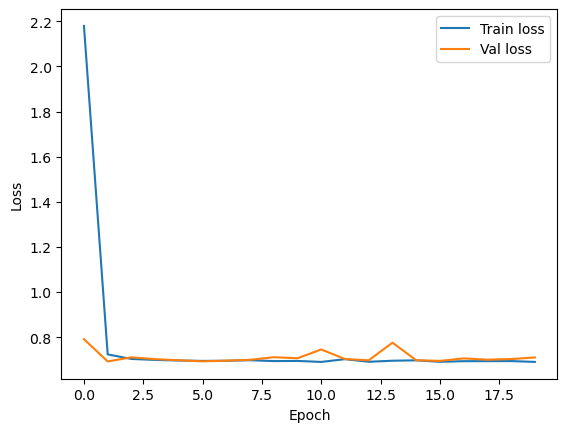

In [87]:
test_loss = 0
correct = 0

vit.eval()
for batch in loader_val:
    inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

    with torch.no_grad():
        logits = vit(inputs)
    loss = F.cross_entropy(logits, targets)
    test_loss += loss.item()
    
    pred = logits.argmax(dim=1, keepdim=True)
    correct += pred.eq(targets.view_as(pred)).sum().item()

test_loss /= len(loader_val)
accuracy = correct / len(loader_val.dataset)

print(f'Validation loss: {test_loss:.3f}')
print(f'Validation top-1 accuracy: {accuracy*100}%')

Validation loss: 0.710
Validation top-1 accuracy: 48.529411764705884%


In [88]:
test_loss = 0
correct = 0

vit.eval()
for batch in loader_test:
    inputs, targets = batch['pixel_values'].to(device), batch['label'].to(device)

    with torch.no_grad():
        logits = vit(inputs)
    loss = F.cross_entropy(logits, targets)
    test_loss += loss.item()
    
    pred = logits.argmax(dim=1, keepdim=True)
    correct += pred.eq(targets.view_as(pred)).sum().item()

test_loss /= len(loader_test)
accuracy = correct / len(loader_test.dataset)

print(f'Test loss: {test_loss:.3f}')
print(f'Test top-1 accuracy: {accuracy*100}%')

Test loss: 0.698
Test top-1 accuracy: 51.47299509001637%
